# Library

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load Data

In [ ]:
var_y = pd.read_csv('var_y.csv')
df = pd.read_csv('df.csv')

In [111]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,...,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20,Kelas
0,2,5,5,5,4,5,5,5,5,3,...,2,5,4,4,2,5,4,3,5,LC09
1,2,2,4,3,4,2,4,4,4,3,...,4,4,2,2,2,5,4,5,5,LA09
2,3,2,5,4,2,3,4,5,3,3,...,4,4,3,3,2,3,3,3,2,LB09
3,2,3,4,4,3,3,4,2,2,3,...,4,3,4,4,2,3,3,4,3,LB09
4,1,1,2,3,3,3,4,3,3,4,...,2,2,3,3,2,1,4,4,1,LB09


In [113]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3


# Analysis

In [114]:
print(var_y.shape)
var_y.info()

(44, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Y1      44 non-null     int64 
 1   Y2      44 non-null     int64 
 2   Y3      44 non-null     int64 
 3   Y4      44 non-null     int64 
 4   Y5      44 non-null     int64 
 5   Y6      44 non-null     int64 
 6   Y7      44 non-null     int64 
 7   Y8      44 non-null     int64 
 8   Y9      44 non-null     int64 
 9   Y10     44 non-null     int64 
 10  Y11     44 non-null     int64 
 11  Y12     44 non-null     int64 
 12  Y13     44 non-null     int64 
 13  Y14     44 non-null     int64 
 14  Y15     44 non-null     int64 
 15  Y16     44 non-null     int64 
 16  Y17     44 non-null     int64 
 17  Y18     44 non-null     int64 
 18  Y19     44 non-null     int64 
 19  Y20     44 non-null     int64 
 20  Kelas   44 non-null     object
dtypes: int64(20), object(1)
memory usage: 7.3+ KB


In [116]:
print(df.shape)
df.info()

(44, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Kelas   44 non-null     object
 1   Gender  44 non-null     object
 2   X1      44 non-null     int64 
 3   X2      44 non-null     int64 
 4   X3      44 non-null     int64 
 5   X4      44 non-null     int64 
 6   X5      44 non-null     int64 
 7   X6      44 non-null     int64 
 8   X7      44 non-null     int64 
 9   X8      44 non-null     int64 
 10  X9      44 non-null     int64 
 11  X10     44 non-null     int64 
dtypes: int64(10), object(2)
memory usage: 4.3+ KB


In [117]:
df[['Kelas', 'Gender']].value_counts()

Kelas  Gender
LB09   Pria      14
LC09   Pria      10
LB09   Wanita     6
LE09   Pria       5
LA09   Pria       4
       Wanita     3
LD09   Pria       1
LE09   Wanita     1
Name: count, dtype: int64

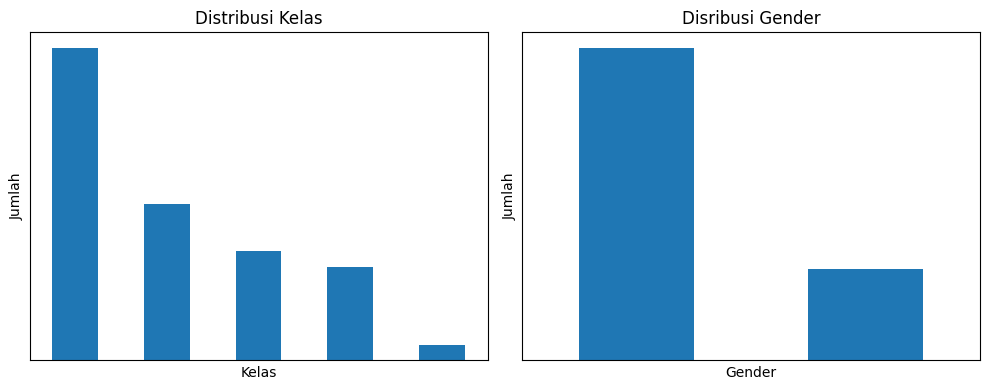

In [118]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df['Kelas'].value_counts().plot(kind = 'bar', ax = ax[0])
ax[0].set_title('Distribusi Kelas')
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Jumlah')
ax[0].set_xticks([])
ax[0].set_yticks([])

df['Gender'].value_counts().plot(kind = 'bar', ax = ax[1])
ax[1].set_xlabel('Gender')
ax[1].set_title('Disribusi Gender')
ax[1].set_ylabel('Jumlah')
ax[1].set_xticks([])
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

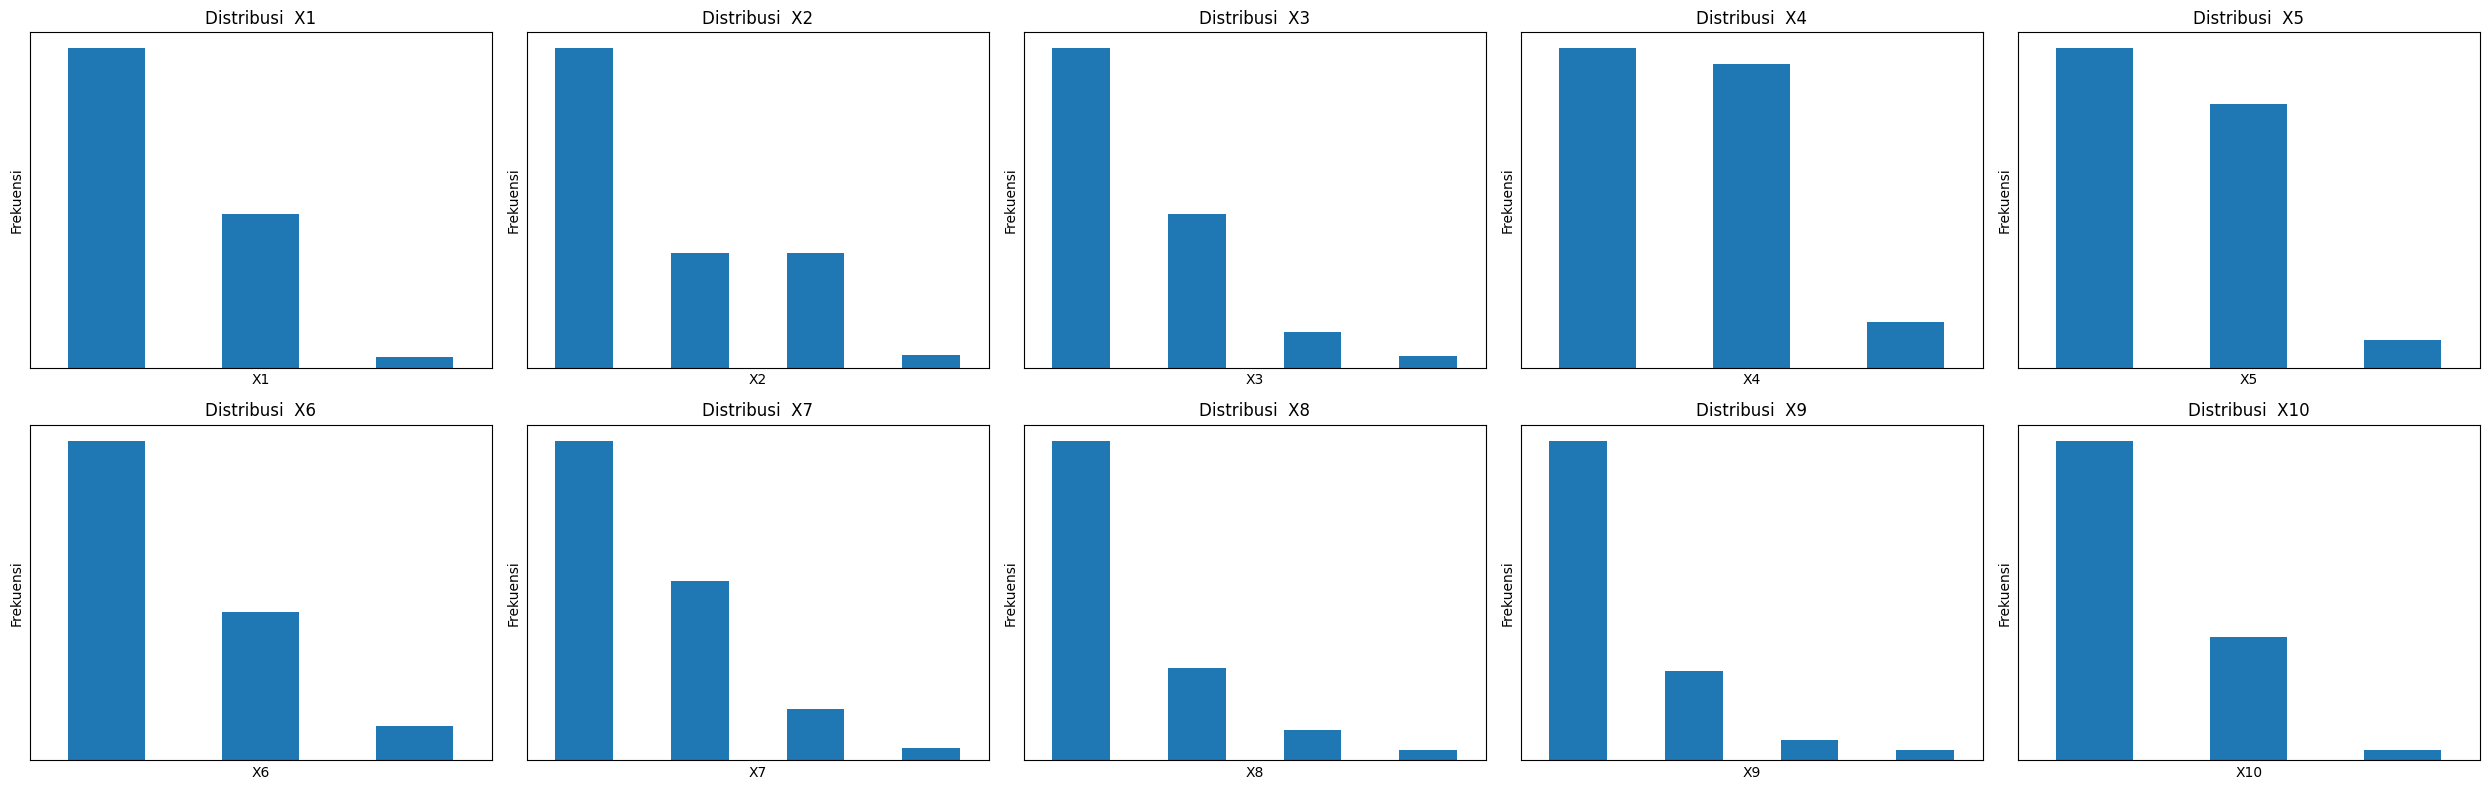

In [119]:
fig, ax = plt.subplots(2, 5, figsize=(25, 8))

ax = ax.flatten()

for i, col in enumerate(var_x.columns):
    var_x[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

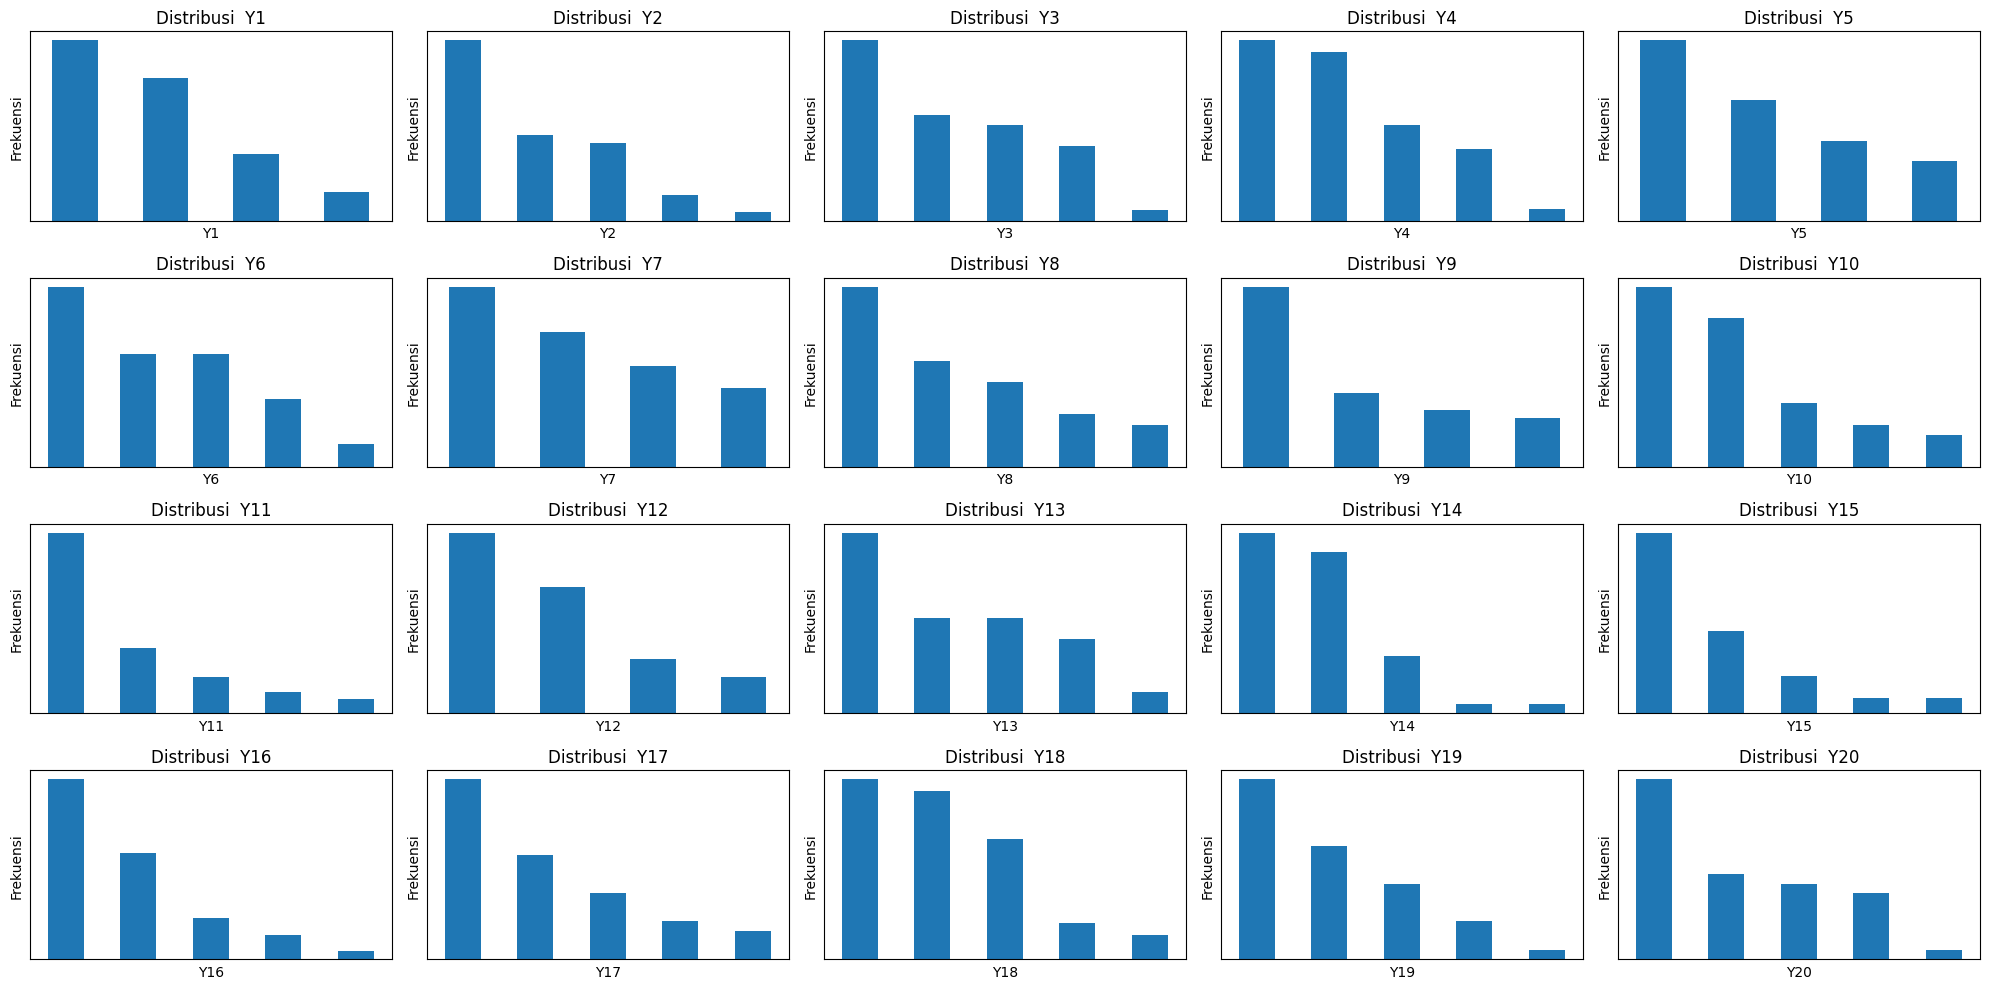

In [120]:
fig, ax = plt.subplots(4, 5, figsize=(20, 10))

ax = ax.flatten()

for i, col in enumerate(var_y.columns[:20]):
    var_y[col].value_counts().plot(kind = 'bar', ax = ax[i])
    ax[i].set_title(f'Distribusi  {col}')
    ax[i].set_xlabel(f'{col}')
    ax[i].set_ylabel('Frekuensi')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
plt.tight_layout()
plt.show()

# Feature Engineering

Populasi tiap Kelas (strata):
- LA09: 
- LB09: 35 mahasiswa
- LC09:
- LD09:
- LE09: 34 mahasiswa

In [121]:
# Populasi tiap kelas (isi sesuai data populasimu)
populasi = {
    'LA09':  45,
    'LB09':  40,
    'LC09':  38,
    'LD09': 42,
    'LE09': 35,
}
total_populasi = sum(populasi.values())

# Proporsi populasi
prop_populasi = {k: v/total_populasi for k, v in populasi.items()}

# Proporsi sampel
prop_sampel = df['Kelas'].value_counts(normalize=True).to_dict()

# Weight = proporsi populasi / proporsi sampel
weight_map = {
    kelas: prop_populasi[kelas] / prop_sampel[kelas]
    for kelas in populasi
}

var_y['weight'] = var_y['Kelas'].map(weight_map)

# Normalisasi
var_y['weight'] = var_y['weight'] / var_y['weight'].sum() * len(var_y)

# Cek hasilnya
summary = var_y.groupby('Kelas').agg(
    n_sampel=('Kelas', 'count'),
    weight=('weight', 'mean')
).assign(
    prop_sampel=lambda d: d['n_sampel']/len(var_y),
    prop_populasi=pd.Series(prop_populasi)
)
print(summary.round(3))

       n_sampel  weight  prop_sampel  prop_populasi
Kelas                                              
LA09          7   1.414        0.159          0.225
LB09         20   0.440        0.455          0.200
LC09         10   0.836        0.227          0.190
LD09          1   9.240        0.023          0.210
LE09          6   1.283        0.136          0.175


In [122]:
var_y.drop(columns = 'Kelas', inplace=True)

In [123]:
var_y.head()

,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10,...,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19,Y20,weight
0,2,5,5,5,4,5,5,5,5,3,...,2,5,4,4,2,5,4,3,5,0.836000
1,2,2,4,3,4,2,4,4,4,3,...,4,4,2,2,2,5,4,5,5,1.414286
2,3,2,5,4,2,3,4,5,3,3,...,4,4,3,3,2,3,3,3,2,0.440000
3,2,3,4,4,3,3,4,2,2,3,...,4,3,4,4,2,3,3,4,3,0.440000
4,1,1,2,3,3,3,4,3,3,4,...,2,2,3,3,2,1,4,4,1,0.440000


# Modeling

## Clustering

In [124]:
kmeans = KMeans(n_clusters = 4, random_state=42)
cluster_sample = var_y.drop('weight', axis = 1)
kmeans.fit(cluster_sample, sample_weight=var_y['weight'])

KMeans(n_clusters=4, random_state=42)

In [128]:
var_y['cluster'] = kmeans.labels_
df['target'] = kmeans.labels_

In [129]:
# Distribusi cluster (weighted)
cluster_summary = var_y.groupby('cluster').agg(
    n_responden=('cluster', 'count'),
    weight_total=('weight', 'sum'),
    weight_mean=('weight', 'mean')
)
cluster_summary['proporsi_weighted'] = (
    cluster_summary['weight_total'] / cluster_summary['weight_total'].sum()
)
print(cluster_summary.round(3))

         n_responden  weight_total  weight_mean  proporsi_weighted
cluster                                                           
0                  4         2.552        0.638              0.058
1                 17        12.751        0.750              0.290
2                 21        19.017        0.906              0.432
3                  2         9.680        4.840              0.220


In [130]:
df.head()

,Kelas,Gender,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,target
0,LC09,Pria,3,3,2,2,3,3,2,3,2,2,0
1,LA09,Wanita,3,2,2,2,2,3,2,2,2,2,2
2,LB09,Pria,4,3,3,2,2,4,3,3,3,2,2
3,LB09,Pria,3,3,3,2,3,4,3,4,3,4,1
4,LB09,Wanita,3,3,2,2,3,3,3,3,3,3,1
